# 03 - CNN desde cero

Entrenamos `SimpleCNN` (definida en `src/models/simple_cnn.py`) sin pesos preentrenados.

Etapas:
1. Setup, config, dataloaders y modelo.
2. Loop de entrenamiento con validacion por epoch.
3. Curvas de loss/accuracy.
4. Evaluacion final en validacion, checkpoint y W&B (opcional).

In [1]:
from __future__ import annotations

import copy
import importlib
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

from src.utils.config import load_yaml_config
from src.utils.reproducibility import set_global_seed

import torch
from torch import nn, optim
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

import src.models.simple_cnn as simple_cnn_module
simple_cnn_module = importlib.reload(simple_cnn_module)
SimpleCNN = simple_cnn_module.SimpleCNN
generate_hparam_candidates = simple_cnn_module.generate_hparam_candidates

from src.training.engine import evaluate_classification, train_one_epoch
from src.utils.wandb_utils import finish_wandb_run, init_wandb_run

CONFIG_PATH = PROJECT_ROOT / "configs" / "scratch_cnn.yaml"
config = load_yaml_config(CONFIG_PATH)
set_global_seed(config["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else config["device"])
print("Device:", device)
config

Device: cuda


{'experiment_name': 'scratch_cnn',
 'seed': 42,
 'device': 'cpu',
 'data': {'root_dir': 'data/asl_alphabet_v1/processed',
  'train_subdir': 'train',
  'val_subdir': 'val',
  'image_size': 128,
  'batch_size': 32,
  'num_workers': 0},
 'training': {'epochs': 10, 'learning_rate': 0.001, 'weight_decay': 0.0},
 'model': {'num_classes': None, 'channels': [16, 32, 64], 'dropout': 0.2},
 'tracking': {'use_wandb': True,
  'project': 'image-classification',
  'run_name': 'scratch-cnn',
  'tags': ['scratch', 'cnn']},
 'hparam_search': {'enabled': True,
  'strategy': 'random',
  'seed': 22,
  'n_trials': 4,
  'max_trials': 12,
  'param_grid': {'learning_rate': [0.001, 0.0005, 0.0001],
   'weight_decay': [0.0, 0.0001],
   'dropout': [0.2, 0.3, 0.5],
   'channels': [[16, 32, 64], [32, 64, 128]],
   'batch_size': [32, 64],
   'epochs': 8}},
 'output': {'artifacts_dir': 'artifacts', 'checkpoint_name': 'scratch_cnn.pt'}}

## Data loaders

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets

from src.data.dataset import build_image_transforms, load_imagefolder_datasets

data_root = PROJECT_ROOT / config["data"]["root_dir"]
image_size = config["data"]["image_size"]
default_batch_size = config["data"]["batch_size"]
num_workers = config["data"].get("num_workers", 0)

train_dataset, val_dataset = load_imagefolder_datasets(
    root_dir=data_root,
    train_subdir=config["data"].get("train_subdir", "train"),
    val_subdir=config["data"].get("val_subdir", "val"),
    image_size=image_size,
)

transform = build_image_transforms(image_size=image_size)
test_subdir = config["data"].get("test_subdir", "test")
test_dir = data_root / test_subdir
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform) if test_dir.exists() else None


def make_loaders(batch_size: int) -> tuple[DataLoader, DataLoader, DataLoader | None]:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = None
    if test_dataset is not None:
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader


@torch.no_grad()
def evaluate_split_metrics(model: nn.Module, loader: DataLoader, device: torch.device) -> dict[str, object]:
    model.eval()
    all_targets: list[int] = []
    all_preds: list[int] = []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_targets.extend(labels.tolist())

    if not all_targets:
        return {
            "accuracy": None,
            "precision_macro": None,
            "recall_macro": None,
            "f1_macro": None,
            "precision_weighted": None,
            "recall_weighted": None,
            "f1_weighted": None,
            "confusion_matrix": None,
        }

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(all_targets, all_preds),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": confusion_matrix(all_targets, all_preds).tolist(),
    }


class_names = train_dataset.classes
num_classes = len(class_names)
print({
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": 0 if test_dataset is None else len(test_dataset),
    "num_classes": num_classes,
})

{'train': 73950, 'val': 13050, 'test': 0, 'num_classes': 29}


## Modelo, criterio y optimizador

In [3]:
base_hparams = {
    "learning_rate": config["training"]["learning_rate"],
    "weight_decay": config["training"].get("weight_decay", 0.0),
    "dropout": config["model"].get("dropout", 0.2),
    "channels": config["model"].get("channels", [16, 32, 64]),
    "batch_size": default_batch_size,
    "epochs": config["training"]["epochs"],
}

candidates = generate_hparam_candidates(
    base_hparams=base_hparams,
    search_config=config.get("hparam_search"),
)

print(f"Hyperparameter candidates: {len(candidates)}")
candidates[0]

Hyperparameter candidates: 4


{'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'dropout': 0.3,
 'channels': [16, 32, 64],
 'batch_size': 64,
 'epochs': 8}

In [4]:
import os, wandb
print("use_wandb:", config["tracking"]["use_wandb"])
print("WANDB_API_KEY exists:", bool(os.getenv("WANDB_API_KEY")))
print("WANDB_PROJECT env:", os.getenv("WANDB_PROJECT"))
print("wandb version:", wandb.__version__)

use_wandb: True
WANDB_API_KEY exists: True
WANDB_PROJECT env: image-classification
wandb version: 0.26.1


## Loop de entrenamiento

In [5]:
search_results = []
best_result = None
best_model_state = None

for trial_idx, trial_hparams in enumerate(candidates, start=1):
    trial_hparams = copy.deepcopy(trial_hparams)
    trial_batch_size = int(trial_hparams["batch_size"])
    trial_epochs = int(trial_hparams["epochs"])

    train_loader, val_loader, test_loader = make_loaders(batch_size=trial_batch_size)

    model = SimpleCNN(
        num_classes=num_classes,
        channels=trial_hparams["channels"],
        dropout=float(trial_hparams["dropout"]),
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=float(trial_hparams["learning_rate"]),
        weight_decay=float(trial_hparams["weight_decay"]),
    )

    trial_name = f"{config['tracking'].get('run_name', config['experiment_name'])}-trial-{trial_idx:02d}"
    run = init_wandb_run(
        config={"trial_idx": trial_idx, "hparams": trial_hparams},
        enabled=config["tracking"].get("use_wandb", False),
        project=config["tracking"]["project"],
        run_name=trial_name,
        tags=(config["tracking"].get("tags") or []) + ["hparam-search"],
    )

    history = []
    for epoch in range(1, trial_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_classification(model, val_loader, criterion, device)
        entry = {
            "trial": trial_idx,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        }
        history.append(entry)
        if run is not None:
            run.log(entry)
        print(
            f"Trial {trial_idx:02d}/{len(candidates):02d} | "
            f"Epoch {epoch:02d}/{trial_epochs:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    final_train_loss, final_train_acc = evaluate_classification(model, train_loader, criterion, device)
    final_val_loss, final_val_acc = evaluate_classification(model, val_loader, criterion, device)

    final_test_loss = None
    final_test_acc = None
    if test_loader is not None:
        final_test_loss, final_test_acc = evaluate_classification(model, test_loader, criterion, device)

    train_metrics = evaluate_split_metrics(model, train_loader, device)
    val_metrics = evaluate_split_metrics(model, val_loader, device)
    test_metrics = evaluate_split_metrics(model, test_loader, device) if test_loader is not None else {
        "accuracy": None,
        "precision_macro": None,
        "recall_macro": None,
        "f1_macro": None,
        "precision_weighted": None,
        "recall_weighted": None,
        "f1_weighted": None,
        "confusion_matrix": None,
    }

    trial_result = {
        "trial": trial_idx,
        "params": trial_hparams,
        "history": history,
        "train_loss": final_train_loss,
        "train_accuracy": final_train_acc,
        "val_loss": final_val_loss,
        "val_accuracy": final_val_acc,
        "test_loss": final_test_loss,
        "test_accuracy": final_test_acc,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "num_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }
    search_results.append(trial_result)

    if run is not None:
        run.log(
            {
                "final_train_loss": final_train_loss,
                "final_train_accuracy": final_train_acc,
                "final_val_loss": final_val_loss,
                "final_val_accuracy": final_val_acc,
                "final_test_loss": final_test_loss,
                "final_test_accuracy": final_test_acc,
                "final_train_precision_macro": train_metrics["precision_macro"],
                "final_train_recall_macro": train_metrics["recall_macro"],
                "final_train_f1_macro": train_metrics["f1_macro"],
                "final_val_precision_macro": val_metrics["precision_macro"],
                "final_val_recall_macro": val_metrics["recall_macro"],
                "final_val_f1_macro": val_metrics["f1_macro"],
                "final_test_precision_macro": test_metrics["precision_macro"],
                "final_test_recall_macro": test_metrics["recall_macro"],
                "final_test_f1_macro": test_metrics["f1_macro"],
            }
        )
        finish_wandb_run(run)

    if best_result is None or trial_result["val_accuracy"] > best_result["val_accuracy"]:
        best_result = trial_result
        best_model_state = copy.deepcopy(model.state_dict())

print("Best trial:")
print(json.dumps({
    "trial": best_result["trial"],
    "params": best_result["params"],
    "train_accuracy": best_result["train_accuracy"],
    "val_accuracy": best_result["val_accuracy"],
    "test_accuracy": best_result["test_accuracy"],
    "train_f1_macro": best_result["train_metrics"]["f1_macro"],
    "val_f1_macro": best_result["val_metrics"]["f1_macro"],
    "test_f1_macro": best_result["test_metrics"]["f1_macro"],
}, indent=2))

history = best_result["history"]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: 202531116 (adne-image-classification) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Trial 01/04 | Epoch 01/08 | train_loss=2.8244 val_loss=2.0433 val_acc=0.3902
Trial 01/04 | Epoch 02/08 | train_loss=1.8939 val_loss=1.4390 val_acc=0.5975
Trial 01/04 | Epoch 03/08 | train_loss=1.5175 val_loss=1.1467 val_acc=0.6766
Trial 01/04 | Epoch 04/08 | train_loss=1.2697 val_loss=0.9026 val_acc=0.7667
Trial 01/04 | Epoch 05/08 | train_loss=1.0848 val_loss=0.7610 val_acc=0.8028
Trial 01/04 | Epoch 06/08 | train_loss=0.9405 val_loss=0.6518 val_acc=0.8382
Trial 01/04 | Epoch 07/08 | train_loss=0.8253 val_loss=0.5475 val_acc=0.8609
Trial 01/04 | Epoch 08/08 | train_loss=0.7290 val_loss=0.4495 val_acc=0.8914


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▄▅▆▇█
final_train_accuracy,▁
final_train_f1_macro,▁
final_train_loss,▁
final_train_precision_macro,▁
final_train_recall_macro,▁
final_val_accuracy,▁
final_val_f1_macro,▁
final_val_loss,▁
final_val_precision_macro,▁
+6,...


Trial 02/04 | Epoch 01/08 | train_loss=2.7283 val_loss=1.8990 val_acc=0.4490
Trial 02/04 | Epoch 02/08 | train_loss=1.7128 val_loss=1.2709 val_acc=0.6454
Trial 02/04 | Epoch 03/08 | train_loss=1.2937 val_loss=1.0033 val_acc=0.6994
Trial 02/04 | Epoch 04/08 | train_loss=1.0459 val_loss=0.7278 val_acc=0.8025
Trial 02/04 | Epoch 05/08 | train_loss=0.8498 val_loss=0.5618 val_acc=0.8620
Trial 02/04 | Epoch 06/08 | train_loss=0.6979 val_loss=0.4373 val_acc=0.8889
Trial 02/04 | Epoch 07/08 | train_loss=0.5782 val_loss=0.3486 val_acc=0.9146
Trial 02/04 | Epoch 08/08 | train_loss=0.4818 val_loss=0.2691 val_acc=0.9419


...

epoch,▁▂▃▄▅▆▇█
final_train_accuracy,▁
final_train_f1_macro,▁
final_train_loss,▁
final_train_precision_macro,▁
final_train_recall_macro,▁
final_val_accuracy,▁
final_val_f1_macro,▁
final_val_loss,▁
final_val_precision_macro,▁
+6,...


Trial 04/04 | Epoch 01/08 | train_loss=3.3341 val_loss=3.2379 val_acc=0.0805
Trial 04/04 | Epoch 02/08 | train_loss=3.1985 val_loss=3.0964 val_acc=0.1193
Trial 04/04 | Epoch 03/08 | train_loss=3.0985 val_loss=2.9944 val_acc=0.1348
Trial 04/04 | Epoch 04/08 | train_loss=3.0146 val_loss=2.8927 val_acc=0.1651
Trial 04/04 | Epoch 05/08 | train_loss=2.9295 val_loss=2.7961 val_acc=0.2004
Trial 04/04 | Epoch 06/08 | train_loss=2.8487 val_loss=2.6917 val_acc=0.2451
Trial 04/04 | Epoch 07/08 | train_loss=2.7549 val_loss=2.5881 val_acc=0.2646
Trial 04/04 | Epoch 08/08 | train_loss=2.6689 val_loss=2.4848 val_acc=0.2969


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▄▅▆▇█
final_train_accuracy,▁
final_train_f1_macro,▁
final_train_loss,▁
final_train_precision_macro,▁
final_train_recall_macro,▁
final_val_accuracy,▁
final_val_f1_macro,▁
final_val_loss,▁
final_val_precision_macro,▁
+6,...


Best trial:
{
  "trial": 3,
  "params": {
    "learning_rate": 0.001,
    "weight_decay": 0.0,
    "dropout": 0.2,
    "channels": [
      32,
      64,
      128
    ],
    "batch_size": 64,
    "epochs": 8
  },
  "train_accuracy": 0.989263015551048,
  "val_accuracy": 0.9881226053639847,
  "test_accuracy": null,
  "train_f1_macro": 0.9892769856579483,
  "val_f1_macro": 0.9881353075797402,
  "test_f1_macro": null
}


## Curvas de loss/accuracy

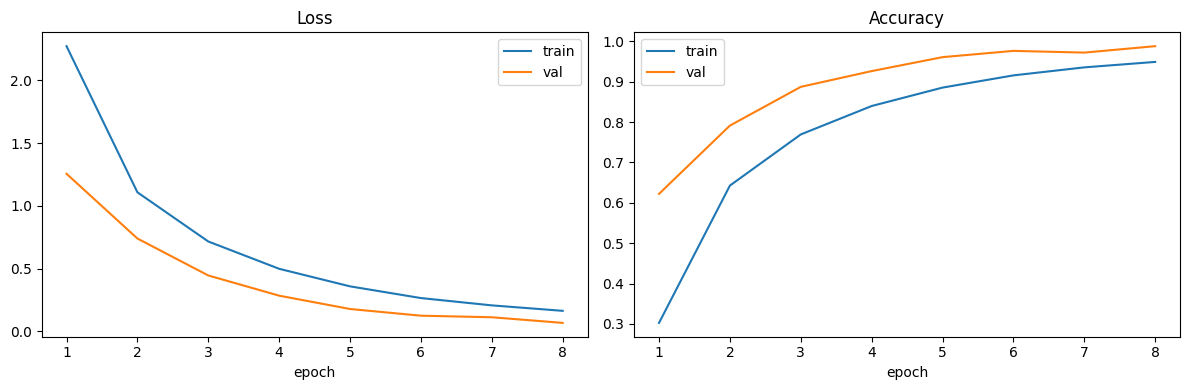

In [6]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [h["train_loss"] for h in history], label="train")
axes[0].plot(epochs, [h["val_loss"] for h in history], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(epochs, [h["train_accuracy"] for h in history], label="train")
axes[1].plot(epochs, [h["val_accuracy"] for h in history], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## Evaluacion final en validacion y guardado del checkpoint

In [7]:
if best_result is None:
    raise RuntimeError("No trial results were generated.")

best_batch_size = int(best_result["params"]["batch_size"])
train_loader, val_loader, test_loader = make_loaders(batch_size=best_batch_size)

best_model = SimpleCNN(
    num_classes=num_classes,
    channels=best_result["params"]["channels"],
    dropout=float(best_result["params"]["dropout"]),
).to(device)
best_model.load_state_dict(best_model_state)
best_model.eval()

criterion = nn.CrossEntropyLoss()
final_train_loss, final_train_acc = evaluate_classification(best_model, train_loader, criterion, device)
final_val_loss, final_val_acc = evaluate_classification(best_model, val_loader, criterion, device)
final_test_loss = None
final_test_acc = None
if test_loader is not None:
    final_test_loss, final_test_acc = evaluate_classification(best_model, test_loader, criterion, device)

final_train_metrics = evaluate_split_metrics(best_model, train_loader, device)
final_val_metrics = evaluate_split_metrics(best_model, val_loader, device)
final_test_metrics = evaluate_split_metrics(best_model, test_loader, device) if test_loader is not None else {
    "accuracy": None,
    "precision_macro": None,
    "recall_macro": None,
    "f1_macro": None,
    "precision_weighted": None,
    "recall_weighted": None,
    "f1_weighted": None,
    "confusion_matrix": None,
}

print({
    "best_trial": best_result["trial"],
    "final_train_accuracy": final_train_acc,
    "final_val_accuracy": final_val_acc,
    "final_test_accuracy": final_test_acc,
    "final_val_precision_macro": final_val_metrics["precision_macro"],
    "final_val_recall_macro": final_val_metrics["recall_macro"],
    "final_val_f1_macro": final_val_metrics["f1_macro"],
})

output_dir = PROJECT_ROOT / config["output"]["artifacts_dir"] / "scratch_cnn"
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / config["output"]["checkpoint_name"]
torch.save({
    "state_dict": best_model.state_dict(),
    "model_type": "simple_cnn",
    "class_names": class_names,
    "image_size": image_size,
    "channels": best_result["params"]["channels"],
    "dropout": best_result["params"]["dropout"],
    "final_train_metrics": final_train_metrics,
    "final_val_metrics": final_val_metrics,
    "final_test_metrics": final_test_metrics,
    "search_results": [
        {
            "trial": result["trial"],
            "params": result["params"],
            "train_loss": result["train_loss"],
            "val_loss": result["val_loss"],
            "test_loss": result["test_loss"],
            "train_accuracy": result["train_accuracy"],
            "val_accuracy": result["val_accuracy"],
            "test_accuracy": result["test_accuracy"],
            "train_metrics": result["train_metrics"],
            "val_metrics": result["val_metrics"],
            "test_metrics": result["test_metrics"],
        }
        for result in search_results
    ],
    "best_trial": best_result["trial"],
}, checkpoint_path)
print("Saved best checkpoint to", checkpoint_path)

{'best_trial': 3, 'final_train_accuracy': 0.989263015551048, 'final_val_accuracy': 0.9881226053639847, 'final_test_accuracy': None, 'final_val_precision_macro': 0.9882779262271867, 'final_val_recall_macro': 0.9881226053639848, 'final_val_f1_macro': 0.9881353075797402}
Saved best checkpoint to c:\Users\torre\Desktop\Big Data\ADNE\signlanguage-classifier\artifacts\scratch_cnn\scratch_cnn.pt
